<a href="https://colab.research.google.com/github/Davron030901/Machine_Learning/blob/main/mashable_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📰 Mashable News Popularity Prediction
**Scenario 09 · Module 3 + Module 4 · Full Lab**

**Maqsad:** Maqola nashr etilishidan *oldin* uning mashhur bo'lishini (`is_popular`) bashorat qilish.

| | |
|---|---|
| **Dataset** | `online_news_popularity.csv` |
| **Rows** | 39,644 Mashable articles (2013–2015) |
| **Target** | `is_popular` (1 = mashhur, 0 = mashhur emas) |

---
**Modul tuzilishi:**
- 🧹 **Module 3 (Class 1–6):** Ma'lumotlarni tozalash va preprocessing
- 🤖 **Module 4 (Class 7–9):** Model o'qitish va baholash

## ⚙️ Setup — Data upload


In [ ]:
# GitHub raw (asl matn) ko'rinishidagi havola
url = "https://raw.githubusercontent.com/Davron030901/Machine_Learning/main/data/online_news_popularity.csv"

# Ma'lumotlarni o'qish


## 📦 Kutubxonalar import qilish

In [ ]:
# pandas  — data loading, cleaning, and manipulation
import pandas as pd

# matplotlib / seaborn — visualisation libraries for charts and plots
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn — machine learning: splitting, scaling, models, metrics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,           # Fraction of all correct predictions
    precision_score,          # Of predicted "popular", how many were truly popular
    recall_score,             # Of all truly popular articles, how many did we catch
    f1_score,                 # Harmonic mean of precision and recall
    confusion_matrix,         # 2x2 table: TP, FP, TN, FN
    ConfusionMatrixDisplay    # Matplotlib wrapper for a pretty confusion matrix
)

import warnings
warnings.filterwarnings('ignore')   # Suppress convergence warnings from LogisticRegression

print("✅ All libraries imported successfully.")

✅ All libraries imported successfully.


---
# 🧹 MODULE 3 — Clean & Preprocess
---

## Class 1 — Ma'lumotlarni yuklash va ko'rish

In [ ]:
# Load the raw CSV from Google Drive into a pandas DataFrame
df = pd.read_csv(url)
# CRITICAL: Every column name has a leading space (e.g. " shares" not "shares").
# strip() removes whitespace from ALL column names in one line.
# Without this fix, df['shares'] raises KeyError throughout the notebook.
df.columns = df.columns.str.strip()

print("Shape:", df.shape)      # Expected: (39644, 61)
print("Columns:", df.columns.tolist())

Shape: (39644, 61)
Columns: ['url', 'timedelta', 'n_tokens_title', 'n_tokens_content', 'n_unique_tokens', 'n_non_stop_words', 'n_non_stop_unique_tokens', 'num_hrefs', 'num_self_hrefs', 'num_imgs', 'num_videos', 'average_token_length', 'num_keywords', 'data_channel_is_lifestyle', 'data_channel_is_entertainment', 'data_channel_is_bus', 'data_channel_is_socmed', 'data_channel_is_tech', 'data_channel_is_world', 'kw_min_min', 'kw_max_min', 'kw_avg_min', 'kw_min_max', 'kw_max_max', 'kw_avg_max', 'kw_min_avg', 'kw_max_avg', 'kw_avg_avg', 'self_reference_min_shares', 'self_reference_max_shares', 'self_reference_avg_sharess', 'weekday_is_monday', 'weekday_is_tuesday', 'weekday_is_wednesday', 'weekday_is_thursday', 'weekday_is_friday', 'weekday_is_saturday', 'weekday_is_sunday', 'is_weekend', 'LDA_00', 'LDA_01', 'LDA_02', 'LDA_03', 'LDA_04', 'global_subjectivity', 'global_sentiment_polarity', 'global_rate_positive_words', 'global_rate_negative_words', 'rate_positive_words', 'rate_negative_words'

In [ ]:
# Always look at the data before touching it.
# describe() gives count, mean, std, min, quartiles, max for each numeric column.
df[['n_tokens_content', 'num_imgs', 'num_videos', 'shares']].describe().round(2)

,n_tokens_content,num_imgs,num_videos,shares
count,39644.00,39644.00,39644.00,39644.00
mean,546.51,4.54,1.25,3395.38
std,471.11,8.31,4.11,11626.95
min,0.00,0.00,0.00,1.00
25%,246.00,1.00,0.00,946.00
50%,409.00,1.00,0.00,1400.00
75%,716.00,4.00,1.00,2800.00
max,8474.00,128.00,91.00,843300.00


In [ ]:
# Show the first 5 rows to get a feel for the raw data
df.head()

,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
0,http://mashable.com/2013/01/07/amazon-instant-...,731.0,12.0,219.0,0.663594,1.0,0.815385,4.0,2.0,1.0,...,0.100000,0.7,-0.350000,-0.600,-0.200000,0.500000,-0.187500,0.000000,0.187500,593
1,http://mashable.com/2013/01/07/ap-samsung-spon...,731.0,9.0,255.0,0.604743,1.0,0.791946,3.0,1.0,1.0,...,0.033333,0.7,-0.118750,-0.125,-0.100000,0.000000,0.000000,0.500000,0.000000,711
2,http://mashable.com/2013/01/07/apple-40-billio...,731.0,9.0,211.0,0.575130,1.0,0.663866,3.0,1.0,1.0,...,0.100000,1.0,-0.466667,-0.800,-0.133333,0.000000,0.000000,0.500000,0.000000,1500
3,http://mashable.com/2013/01/07/astronaut-notre...,731.0,9.0,531.0,0.503788,1.0,0.665635,9.0,0.0,1.0,...,0.136364,0.8,-0.369697,-0.600,-0.166667,0.000000,0.000000,0.500000,0.000000,1200
4,http://mashable.com/2013/01/07/att-u-verse-apps/,731.0,13.0,1072.0,0.415646,1.0,0.540890,19.0,19.0,20.0,...,0.033333,1.0,-0.220192,-0.500,-0.050000,0.454545,0.136364,0.045455,0.136364,505


## Class 2 — Buziq qatorlarni topish va o'chirish

In [ ]:
# ── Problem 1: Empty articles ─────────────────────────────────────────────
# n_tokens_content == 0 means the article has NO body text.
# These rows carry zero predictive signal and must be removed.
empty = (df['n_tokens_content'] == 0).sum()
print("Empty articles (content == 0):", empty)   # Expected: 1181

# Keep only rows where the article has at least 1 word in its body
df = df[df['n_tokens_content'] > 0]
print("Rows after removing empty articles:", df.shape[0])

Empty articles (content == 0): 1181
Rows after removing empty articles: 38463


In [ ]:
# ── Problem 2: Corrupt outlier value ─────────────────────────────────────
# n_non_stop_words is a ratio that must always be between 0 and 1.
# One row has the value 1042 — clearly a data entry error.
# Leaving it in would massively distort StandardScaler for ALL features.
print("Max n_non_stop_words BEFORE:", df['n_non_stop_words'].max())   # Shows 1042.0

# Remove the single row where the ratio is physically impossible
df = df[df['n_non_stop_words'] <= 1]

print("Max n_non_stop_words AFTER :", df['n_non_stop_words'].max())   # Shows ~1.0
print("Rows after full cleaning   :", df.shape[0])                    # Expected: 38462

Max n_non_stop_words BEFORE: 1042.0
Max n_non_stop_words AFTER : 0.99999999978
Rows after full cleaning   : 38462


### 📊 Shares distribution — nima uchun median split to'g'ri?

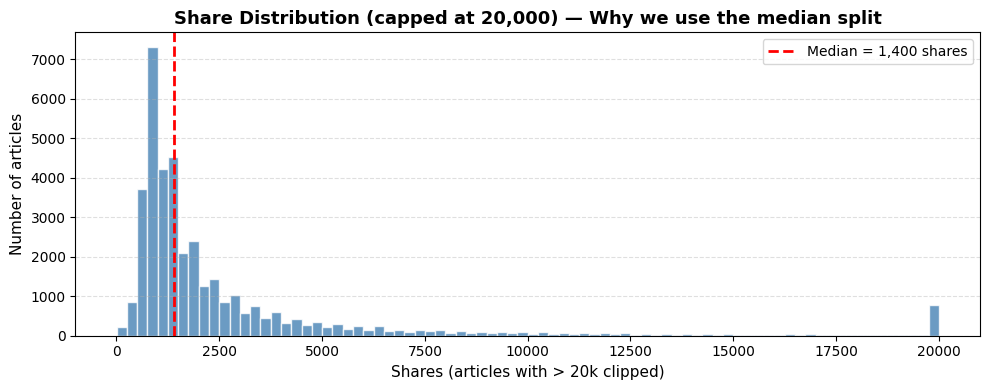

In [ ]:
# Visualise the share distribution to understand WHY we use the median.
# The distribution is right-skewed: a few viral articles (up to 843,000 shares)
# drag the mean far right. The median sits at the true midpoint.

fig, ax = plt.subplots(figsize=(10, 4))

# Clip the x-axis at 20,000 to make the chart readable (extreme outliers would squash the histogram)
ax.hist(df['shares'].clip(upper=20000), bins=80, color='steelblue', edgecolor='white', alpha=0.8)

# Draw a vertical red dashed line at the median to show the split point
ax.axvline(df['shares'].median(), color='red', linestyle='--', linewidth=2,
           label=f"Median = {int(df['shares'].median()):,} shares")

ax.set_title("Share Distribution (capped at 20,000) — Why we use the median split",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Shares (articles with > 20k clipped)", fontsize=11)
ax.set_ylabel("Number of articles", fontsize=11)
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

## Class 3 — Predictive bo'lmagan ustunlarni o'chirish

In [ ]:
# Two columns must be dropped before modelling:
#   'url'       — plain text (a hyperlink), not a number a model can use
#   'timedelta' — days since collection; reflects data-gathering timing, NOT article quality
#                 Using it would let the model cheat by learning about time, not content.
df = df.drop(columns=['url', 'timedelta'])

print("Columns after dropping url & timedelta:", df.shape[1])   # Expected: 59

Columns after dropping url & timedelta: 59


## Class 4 — Section (channel) ustunlarini tushunish

Articles per channel:
data_channel_is_lifestyle        2077.0
data_channel_is_socmed           2311.0
data_channel_is_bus              6235.0
data_channel_is_entertainment    6855.0
data_channel_is_tech             7325.0
data_channel_is_world            8168.0


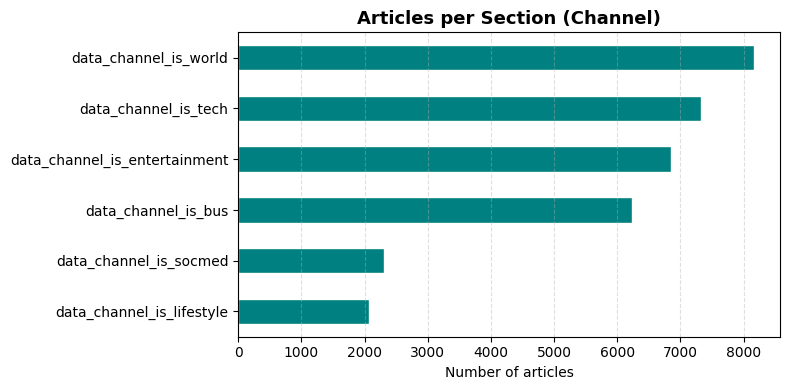

In [ ]:
# Mashable groups articles into 6 sections, represented as one-hot binary columns.
# One-hot encoding = one column per category, value 0 or 1.
# ~15% of articles are 0 in ALL six columns — they had no section tag (that is fine).

channel_cols = [
    'data_channel_is_lifestyle',      # Lifestyle articles
    'data_channel_is_entertainment',  # Entertainment news
    'data_channel_is_bus',            # Business articles
    'data_channel_is_socmed',         # Social media topics
    'data_channel_is_tech',           # Technology articles
    'data_channel_is_world'           # World / international news
]

# Count how many articles belong to each section
channel_counts = df[channel_cols].sum().sort_values(ascending=True)
print("Articles per channel:")
print(channel_counts.to_string())

# Bar chart to visually compare section sizes
fig, ax = plt.subplots(figsize=(8, 4))
channel_counts.plot.barh(ax=ax, color='teal', edgecolor='white')
ax.set_title("Articles per Section (Channel)", fontsize=13, fontweight='bold')
ax.set_xlabel("Number of articles")
ax.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

## Class 5 — Target ustunini yaratish (`is_popular`)

In [ ]:
# Convert the continuous 'shares' column into a binary target label.
# WHY MEDIAN?
#   The mean is inflated by viral outliers (up to 843,000 shares).
#   Splitting at the mean would label almost every article as "not popular".
#   The median is the true midpoint of the sorted list → balanced 50/50 classes.

median_shares = df['shares'].median()          # Find the middle value of all share counts
print("Median shares:", median_shares)         # Expected: 1400.0

# Articles with shares >= median are labelled 1 (popular); below median = 0 (not popular)
df['is_popular'] = (df['shares'] >= median_shares).astype(int)

print("\nTarget distribution:")
print(df['is_popular'].value_counts().to_string())
# Should be roughly 50/50 — both classes approximately equal in size

Median shares: 1400.0

Target distribution:
is_popular
1    20463
0    17999


## Class 6 — Final ustunlar tanlash va saqlash (Module 3 deliverable)

In [ ]:
# Select exactly 18 pre-publish features — facts known BEFORE the article goes live.
# We deliberately exclude 'shares' to prevent data leakage:
#   is_popular was built from shares, so including shares would be cheating.

feature_columns = [
    'n_tokens_title',                # Number of words in the title
    'n_tokens_content',              # Number of words in the article body
    'num_hrefs',                     # Total hyperlinks in the article
    'num_self_hrefs',                # Links pointing back to Mashable
    'num_imgs',                      # Images embedded in the article
    'num_videos',                    # Videos embedded in the article
    'num_keywords',                  # Keywords/tags assigned to the article
    'data_channel_is_lifestyle',     # Binary: Lifestyle section?
    'data_channel_is_entertainment', # Binary: Entertainment section?
    'data_channel_is_bus',           # Binary: Business section?
    'data_channel_is_socmed',        # Binary: Social Media section?
    'data_channel_is_tech',          # Binary: Tech section?
    'data_channel_is_world',         # Binary: World News section?
    'is_weekend',                    # Binary: published on Saturday or Sunday?
    'global_subjectivity',           # How opinion-based the full article text is (0–1)
    'global_sentiment_polarity',     # Overall positive/negative tone (-1 to +1)
    'title_subjectivity',            # How subjective the title is (0–1)
    'title_sentiment_polarity',      # Positive/negative tone of the title (-1 to +1)
]

# Build the final cleaned DataFrame with only our chosen features + target
final_df = df[feature_columns + ['is_popular']].copy()

# Add a sequential article ID at position 0 for row traceability
final_df.insert(0, 'article_id', range(len(final_df)))

print("Final shape:", final_df.shape)   # Expected: (38462, 20)
final_df.head()

Final shape: (38462, 20)


,article_id,n_tokens_title,n_tokens_content,num_hrefs,num_self_hrefs,num_imgs,num_videos,num_keywords,data_channel_is_lifestyle,data_channel_is_entertainment,data_channel_is_bus,data_channel_is_socmed,data_channel_is_tech,data_channel_is_world,is_weekend,global_subjectivity,global_sentiment_polarity,title_subjectivity,title_sentiment_polarity,is_popular
0,0,12.0,219.0,4.0,2.0,1.0,0.0,5.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.521617,0.092562,0.500000,-0.187500,0
1,1,9.0,255.0,3.0,1.0,1.0,0.0,4.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.341246,0.148948,0.000000,0.000000,0
2,2,9.0,211.0,3.0,1.0,1.0,0.0,6.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.702222,0.323333,0.000000,0.000000,1
3,3,9.0,531.0,9.0,0.0,1.0,0.0,7.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.429850,0.100705,0.000000,0.000000,0
4,4,13.0,1072.0,19.0,19.0,20.0,0.0,7.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.513502,0.281003,0.454545,0.136364,0


In [ ]:
import pathlib

# Save the clean dataset as Parquet — a typed, compressed columnar format.
# Parquet is preferred over CSV here because:
#   1. It preserves dtypes (int, float) — no type guessing on reload.
#   2. It is typically 3–5x smaller than CSV for numeric data.
#   3. It loads faster with pd.read_parquet() than pd.read_csv().

PARQUET_PATH = '/content/drive/MyDrive/mashable_lab/mashable_clean.parquet'

# Create the directory if it doesn't exist
pathlib.Path(PARQUET_PATH).parent.mkdir(parents=True, exist_ok=True)

final_df.to_parquet(PARQUET_PATH)

print("✅ MODULE 3 COMPLETE!")
print(f"   Saved: {PARQUET_PATH}")
print(f"   Rows  : {final_df.shape[0]:,}")
print(f"   Cols  : {final_df.shape[1]} (18 features + article_id + is_popular)")

✅ MODULE 3 COMPLETE!
   Saved: /content/drive/MyDrive/mashable_lab/mashable_clean.parquet
   Rows  : 38,462
   Cols  : 20 (18 features + article_id + is_popular)


---
# 🤖 MODULE 4 — Train & Evaluate
---

## Class 7 — Tozalangan faylni yuklash va split qilish

In [ ]:
# Always reload from the saved Parquet file — proves Module 3 → Module 4
# is a clean handoff with no leftover state from earlier cleaning steps.
df_clean = pd.read_parquet('/content/drive/MyDrive/mashable_lab/mashable_clean.parquet')

print("Loaded shape:", df_clean.shape)
df_clean.head()

Loaded shape: (38462, 20)


,article_id,n_tokens_title,n_tokens_content,num_hrefs,num_self_hrefs,num_imgs,num_videos,num_keywords,data_channel_is_lifestyle,data_channel_is_entertainment,data_channel_is_bus,data_channel_is_socmed,data_channel_is_tech,data_channel_is_world,is_weekend,global_subjectivity,global_sentiment_polarity,title_subjectivity,title_sentiment_polarity,is_popular
0,0,12.0,219.0,4.0,2.0,1.0,0.0,5.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.521617,0.092562,0.500000,-0.187500,0
1,1,9.0,255.0,3.0,1.0,1.0,0.0,4.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.341246,0.148948,0.000000,0.000000,0
2,2,9.0,211.0,3.0,1.0,1.0,0.0,6.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.702222,0.323333,0.000000,0.000000,1
3,3,9.0,531.0,9.0,0.0,1.0,0.0,7.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.429850,0.100705,0.000000,0.000000,0
4,4,13.0,1072.0,19.0,19.0,20.0,0.0,7.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.513502,0.281003,0.454545,0.136364,0


In [ ]:
# Separate features (X) from the target label (y)
X = df_clean[feature_columns]    # 18-column feature matrix — inputs to the model
y = df_clean['is_popular']       # 1D target vector — what we want to predict

# Split into train (80%) and test (20%) sets.
#   test_size=0.2   → 20% of rows held back for unbiased final evaluation
#   random_state=42 → fixed seed so every run produces the EXACT same split
#   stratify=y      → preserves the ~50/50 class ratio in BOTH train and test
#                     Without stratify, one set could end up 60/40 by chance.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train samples : {len(X_train):,}")
print(f"Test  samples : {len(X_test):,}")
print(f"Features      : {X_train.shape[1]}")

Train samples : 30,769
Test  samples : 7,693
Features      : 18


## Class 8 — Masshtablash va ikkita model o'qitish

In [ ]:
# ── Scaling ────────────────────────────────────────────────────────────────
# StandardScaler converts each feature to z-scores: (x - mean) / std
# This centres all features at 0 with std=1 — required for Logistic Regression
# so that no single large-valued feature dominates the gradient updates.
#
# GOLDEN RULE: fit the scaler on TRAIN ONLY.
# Calling fit_transform on the full dataset leaks test-set statistics into training
# → the model "sees" future data → evaluation scores are dishonestly optimistic.

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # Learn mean & std from train; transform train
X_test_sc  = scaler.transform(X_test)        # Apply THE SAME learned parameters to test

print("✅ Scaling done (fitted on train only).")

✅ Scaling done (fitted on train only).


In [ ]:
# ── Model 1: Logistic Regression ──────────────────────────────────────────
# A linear classifier — simple, fast, interpretable.
# Requires scaled features because it optimises a gradient-based loss function.
# max_iter=1000 prevents "ConvergenceWarning" on this dataset size.

model_lr = LogisticRegression(max_iter=1000, random_state=42)
model_lr.fit(X_train_sc, y_train)   # Train on SCALED training data
print("✅ Logistic Regression trained.")

✅ Logistic Regression trained.


In [ ]:
# ── Model 2: Random Forest ────────────────────────────────────────────────
# An ensemble of 100 decision trees — each tree votes and the majority class wins.
# Tree-based models split on raw thresholds, so scaling has no effect on them.
# We train on raw (unscaled) X_train.
# n_estimators=100 balances accuracy vs training time on ~30K rows.

model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)   # Train on RAW (unscaled) training data
print("✅ Random Forest trained.")

✅ Random Forest trained.


## Class 9 — Baholash (eng muhim qadam)

In [ ]:
# Evaluate both models on the HELD-OUT test set they have never seen.
# Four metrics give the complete picture:
#
#   Accuracy  — % of all predictions that are correct
#               Useful here because classes are balanced (~50/50)
#
#   Precision — of articles predicted "popular", what fraction truly went viral?
#               Low precision → we waste promotion budget on articles that flop
#
#   Recall    — of all truly popular articles, what fraction did we catch?
#               Low recall → we miss viral hits and fail to invest in them
#
#   F1        — harmonic mean of precision and recall
#               Punishes a model that is excellent on one but terrible on the other

results = {}   # Store scores for the comparison chart below

for name, model, X_eval in [
    ("Logistic Regression", model_lr, X_test_sc),   # LR needs scaled features
    ("Random Forest",       model_rf, X_test)        # RF uses raw features
]:
    y_pred = model.predict(X_eval)   # Generate class predictions on test set

    acc  = accuracy_score(y_test, y_pred)    # Overall fraction correctly classified
    prec = precision_score(y_test, y_pred)   # Precision for the positive (popular) class
    rec  = recall_score(y_test, y_pred)      # Recall for the positive (popular) class
    f1   = f1_score(y_test, y_pred)          # F1 score for the positive class

    results[name] = {"Accuracy": acc, "Precision": prec, "Recall": rec, "F1": f1}

    print(f"\n=== {name} ===")
    print(f"  Accuracy  : {acc:.3f}")
    print(f"  Precision : {prec:.3f}")
    print(f"  Recall    : {rec:.3f}")
    print(f"  F1        : {f1:.3f}")


=== Logistic Regression ===
  Accuracy  : 0.633
  Precision : 0.642
  Recall    : 0.703
  F1        : 0.671

=== Random Forest ===
  Accuracy  : 0.638
  Precision : 0.652
  Recall    : 0.688
  F1        : 0.669


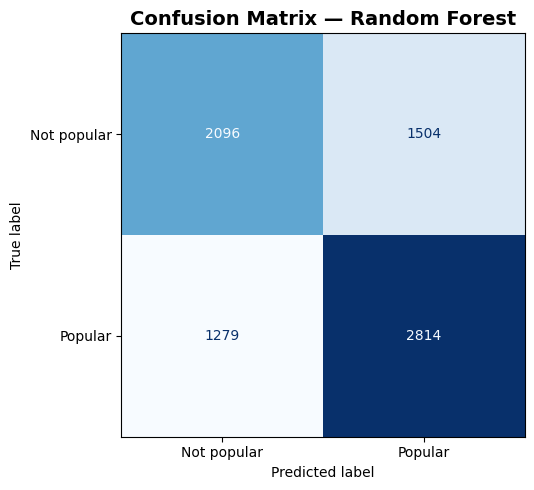

In [ ]:
# ── Confusion Matrix for Random Forest ────────────────────────────────────
# Shows four outcomes:
#   True  Negative (top-left)  — correctly called "not popular"
#   False Positive (top-right) — wrongly called "popular" (it flopped)
#   False Negative (bot-left)  — missed a viral article (called it "not popular")
#   True  Positive (bot-right) — correctly called "popular"

y_pred_rf = model_rf.predict(X_test)              # Predictions from Random Forest
cm = confusion_matrix(y_test, y_pred_rf)          # Compute 2x2 confusion matrix

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Not popular', 'Popular']     # Human-readable axis labels
).plot(ax=ax, colorbar=False, cmap='Blues')       # Blue colour map; no redundant colour bar

ax.set_title("Confusion Matrix — Random Forest", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

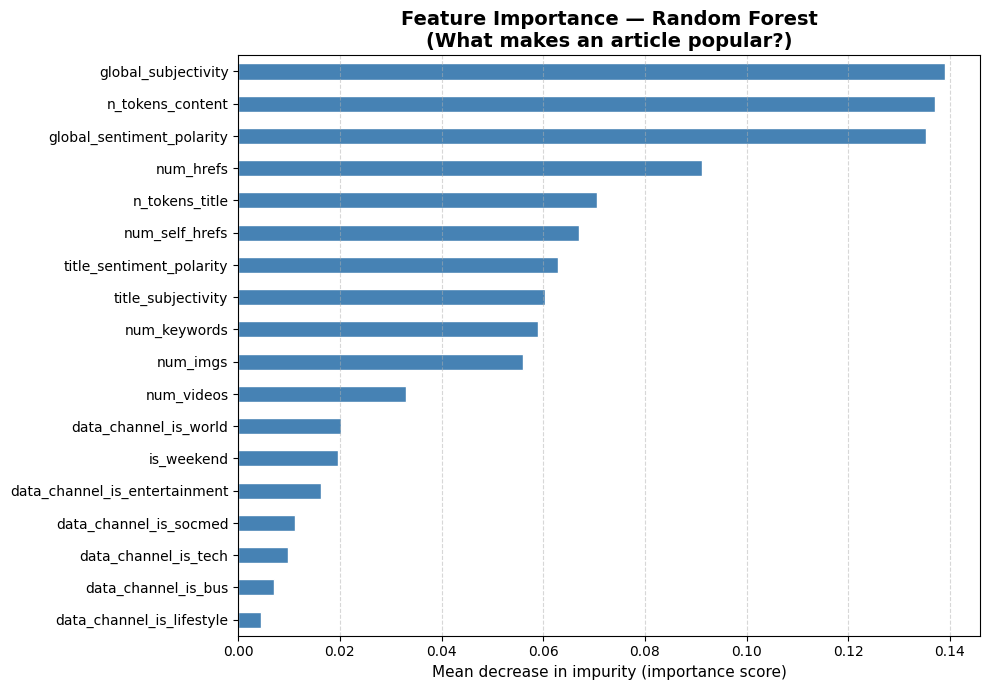


Top 8 most important features:
global_subjectivity          0.1390
n_tokens_content             0.1370
global_sentiment_polarity    0.1354
num_hrefs                    0.0913
n_tokens_title               0.0705
num_self_hrefs               0.0670
title_sentiment_polarity     0.0630
title_subjectivity           0.0604


In [ ]:
# ── Feature Importance ─────────────────────────────────────────────────────
# Random Forest exposes feature_importances_:
# the average reduction in Gini impurity caused by each feature across all 100 trees.
# Higher = the feature splits the data more cleanly = more predictive.

importance = pd.Series(
    model_rf.feature_importances_,   # Raw importance scores from the forest
    index=feature_columns            # Map each score back to the feature name
)
importance_sorted = importance.sort_values(ascending=True)   # Ascending so largest bar is on top

fig, ax = plt.subplots(figsize=(10, 7))
importance_sorted.plot.barh(ax=ax, color='steelblue', edgecolor='white')
ax.set_title("Feature Importance — Random Forest\n(What makes an article popular?)",
             fontsize=14, fontweight='bold')
ax.set_xlabel("Mean decrease in impurity (importance score)", fontsize=11)
ax.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Print the top 8 most important features as a quick reference table
print("\nTop 8 most important features:")
print(importance.sort_values(ascending=False).head(8).round(4).to_string())

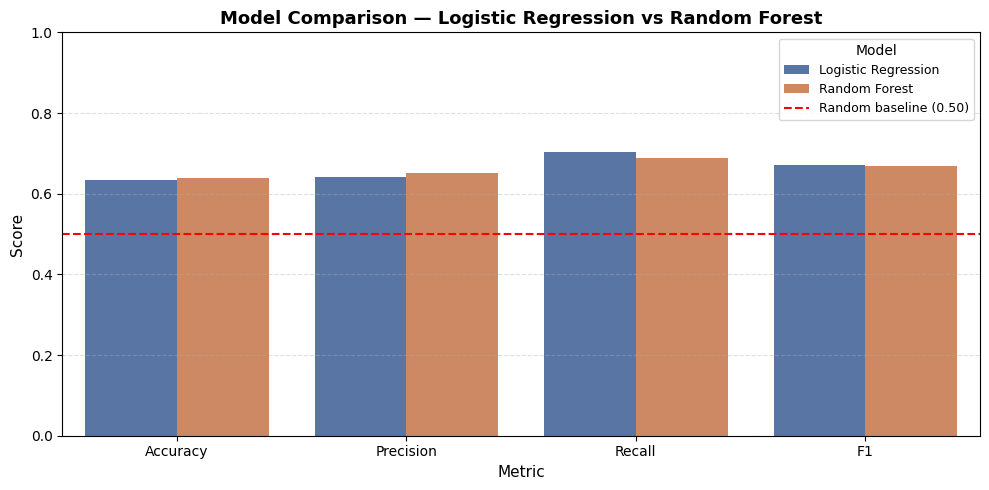

In [ ]:
# ── Model Comparison Chart ─────────────────────────────────────────────────
# Grouped bar chart — lets us compare all 4 metrics across both models at a glance.
# The red dashed line at 0.50 marks the random-coin-flip baseline.
# Both models should comfortably beat it.

metrics     = ['Accuracy', 'Precision', 'Recall', 'F1']
model_names = list(results.keys())

# Build a tidy (long-format) DataFrame for seaborn's grouped barplot
results_df = pd.DataFrame(results).T.reset_index().rename(columns={'index': 'Model'})
results_melted = results_df.melt(
    id_vars='Model',
    value_vars=metrics,
    var_name='Metric',   # Column that holds metric names
    value_name='Score'   # Column that holds the float score values
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    data=results_melted,
    x='Metric', y='Score', hue='Model',
    palette=['#4C72B0', '#DD8452'],   # Blue = LR, Orange = RF
    ax=ax
)

# Random baseline at 50% — any model above this line is actually learning something
ax.axhline(0.50, color='red', linestyle='--', linewidth=1.5, label='Random baseline (0.50)')
ax.set_ylim(0, 1)
ax.set_title('Model Comparison — Logistic Regression vs Random Forest',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Score', fontsize=11)
ax.set_xlabel('Metric', fontsize=11)
ax.legend(title='Model', fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()